In [1]:
import math
import time
import matplotlib.pyplot as plt

#### Hodgkin-Huxley Model

**Overview**: This notebook implements a conductance-based single-neuron model (HH-style) and simulates its dynamics numerically. The key components are gating kinetics, ionic currents, the capacitive membrane equation, and a scalar RK4 integrator used for time-stepping.

**Gating dynamics (per-gate)**

The probability `x` of a gate being open (e.g. $n,m,h$) follows voltage-dependent first-order kinetics:

$$\frac{dx}{dt} = \alpha_x(V)\,(1-x) - \beta_x(V)\,x.$$

Equivalently, using steady-state and time-constant notation:

$$x_\infty(V)=\frac{\alpha_x(V)}{\alpha_x(V)+\beta_x(V)}, \qquad \tau_x(V)=\frac{1}{\alpha_x(V)+\beta_x(V)},$$

so

$$\frac{dx}{dt}=\frac{x_\infty(V)-x}{\tau_x(V)}.$$

**Ionic currents and membrane equation**

The model uses standard Hodgkin–Huxley-style currents:

$$I_K = \bar g_K\,n^4\,(V-E_K),\\
$$
$$I_{Na} = \bar g_{Na}\,m^3 h\,(V-E_{Na}),\\
$$
$$I_L = \bar g_L\,(V-E_L).$$

Membrane capacitance relates voltage change to net current:

$$C_m\frac{dV}{dt} = I_{\mathrm{ext}}(t) - (I_K + I_{Na} + I_L).$$

**Numerical integration (RK4)**

A minimal scalar RK4 step is used for each state variable (gates and V):

$$y_{t+h} = y_t + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4),$$
where $k_1=f(t,y)$ and $k_2=f(t+h/2,\,y+h k_1/2)$ etc. The code implements `step_rk4` and applies it to the gate ODEs and to $V$ each timestep.

**Simulation loop (outline)**

- Initialize $V$ and gate variables at their steady-state values for the starting voltage $V_0$.
- For each timestep:
  - Advance each gate (n, m, h) using RK4 on the gate ODE (depends on current $V$).
  - Compute ionic currents from updated gates and $V$, then advance $V$ via RK4 using `derivative_membrane_voltage`.
  - Record `time`, `V`, and `I_ext` for analysis/plotting.

**Practical notes**: choose `STEP` small enough that RK4 error is acceptable; gates are stiff at some voltages so step size affects stability. The notebook uses a square-like external pulse `I_ext(t)` and records `potentials` and `external_currents` for visualization.

**Modeling remark**: The later MLP attempt treats $(t, I_{ext})\mapsto V(t)$ as a static mapping, which discards internal-state memory (gates). It's clearly a very primitive attempt and something like and LSTM combined with a PINN would be way more successful. This was just a very quick experiment

In [2]:
# Minimal RK4 step for scalars
def step_rk4(y, t, step, dy, **kwargs):
    half = step / 2.0
    k1 = dy(t, y, **kwargs)
    k2 = dy(t + half, y + k1 * half, **kwargs)
    k3 = dy(t + half, y + k2 * half, **kwargs)
    k4 = dy(t + step, y + k3 * step, **kwargs)
    return y + (step / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

In [3]:
# binding math.exp to a local name (_exp) avoids repeated attribute lookups (tiny speed win in tight loops).
def _exp(x):
    return math.exp(x)

# Gating kinetics


def alpha_potassium(v):
    x = (10.0 - v) / 10.0
    denom = _exp(x) - 1.0
    if abs(denom) < 1e-6:
        return 0.1
    return (0.01 * (10.0 - v)) / denom


def beta_potassium(v):
    return 0.125 * _exp(-v / 80.0)


def alpha_sodium_m(v):
    x = (25.0 - v) / 10.0
    denom = _exp(x) - 1.0
    if abs(denom) < 1e-6:
        return 1.0
    return (0.1 * (25.0 - v)) / denom


def beta_sodium_m(v):
    return 4.0 * _exp(-v / 18.0)


def alpha_sodium_h(v):
    return 0.07 * _exp(-v / 20.0)


def beta_sodium_h(v):
    return 1.0 / (_exp((30.0 - v) / 10.0) + 1.0)


# delta gate and steady state
def delta_gate(t, gate_prob, membrane_voltage, alpha_gate, beta_gate):
    a = alpha_gate(membrane_voltage)
    b = beta_gate(membrane_voltage)
    return a * (1.0 - gate_prob) - b * gate_prob


def gate_steady_state(alpha, beta, V):
    return alpha(V) / (alpha(V) + beta(V))

In [73]:
# External current
environment_current_amp = 2.0

# Membrane params
MEMBRANE_CAPACITANCE = 0.5
MAX_CONDUCTIVITY_POTASSIUM = 12.0
REST_POTASSIUM = -90.0
MAX_CONDUCTIVITY_SODIUM = 20.0
REST_SODIUM = 50.0
MAX_CONDUCTIVITY_LEAK = 0.1
REST_LEAK = -60.0

# Simulation params
STEPS = 100000
STEP = 0.01

In [74]:
def I_ext(t):
    state = int(t // 15) % 2
    return environment_current_amp if state == 1 else 0.0


def derivative_membrane_voltage(t, membrane_voltage, potassium_prob, sodium_prob_m, sodium_prob_h):
    potassium_current = MAX_CONDUCTIVITY_POTASSIUM * \
        (potassium_prob ** 4) * (membrane_voltage - REST_POTASSIUM)
    sodium_current = MAX_CONDUCTIVITY_SODIUM * \
        (sodium_prob_m ** 3) * sodium_prob_h * (membrane_voltage - REST_SODIUM)
    leak_current = MAX_CONDUCTIVITY_LEAK * (membrane_voltage - REST_LEAK)
    ionic_current = potassium_current + sodium_current + leak_current
    return (I_ext(t) - ionic_current) / MEMBRANE_CAPACITANCE

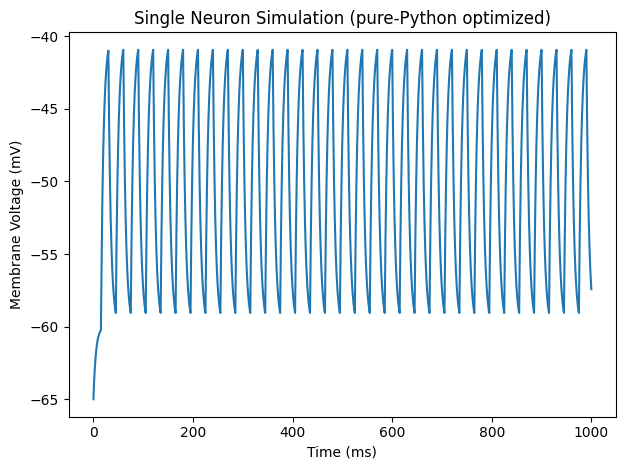

In [75]:

def run_simulation(steps: int = STEPS, step: float = STEP) -> dict[str, list[float]]:
    # Initial conditions
    membrane_voltage = -65.0
    potassium_prob = gate_steady_state(
        alpha_potassium, beta_potassium, membrane_voltage)
    sodium_prob_m = gate_steady_state(
        alpha_sodium_m, beta_sodium_m, membrane_voltage)
    sodium_prob_h = gate_steady_state(
        alpha_sodium_h, beta_sodium_h, membrane_voltage)

    # Preallocate lists
    potentials = [0.0] * steps
    times = [0.0] * steps
    external_currents = [0.0] * steps

    # Run simulation
    t = 0.0
    for i in range(steps):
        potassium_prob = step_rk4(potassium_prob, t, step, delta_gate, alpha_gate=alpha_potassium,
                                  beta_gate=beta_potassium, membrane_voltage=membrane_voltage)
        sodium_prob_m = step_rk4(sodium_prob_m, t, step, delta_gate, alpha_gate=alpha_sodium_m,
                                 beta_gate=beta_sodium_m, membrane_voltage=membrane_voltage)
        sodium_prob_h = step_rk4(sodium_prob_h, t, step, delta_gate, alpha_gate=alpha_sodium_h,
                                 beta_gate=beta_sodium_h, membrane_voltage=membrane_voltage)
        membrane_voltage = step_rk4(membrane_voltage, t, step, derivative_membrane_voltage,
                                    potassium_prob=potassium_prob, sodium_prob_m=sodium_prob_m, sodium_prob_h=sodium_prob_h)
        t += step
        potentials[i] = membrane_voltage
        times[i] = t
        external_currents[i] = I_ext(t)

    return {"times": times, "potentials": potentials, "external_currents": external_currents}


def plot_simulation_results(results: dict[str, list[float]]):
    times = results["times"]
    potentials = results["potentials"]

    plt.xlabel("Time (ms)")
    plt.ylabel("Membrane Voltage (mV)")
    plt.title("Single Neuron Simulation (pure-Python optimized)")
    plt.tight_layout()

    plt.plot(times, potentials)
    plt.show()


results = run_simulation()
plot_simulation_results(results)

##### Building an MLP to obtain a $V(t)$

- Extermely primitive implementation of an MLP
- Check if brute-forcing the problem works
- Next will try lstm architecture

In [76]:
import torch
from torch import nn
import pandas as pd

from sklearn.model_selection import train_test_split

In [77]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [78]:
class MLP(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        x = self.layers(x)
        return x

In [79]:
df = pd.DataFrame(results)
X = torch.tensor(df[["times", "external_currents"]].values,
                 dtype=torch.float32).to(device)
y = torch.tensor(df["potentials"].values,
                 dtype=torch.float32).unsqueeze(1).to(device)

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [82]:
model = MLP(input_size=2, hidden_size=256, output_size=1).to(device)

loss = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [83]:
EPOCHS = 10000

for epoch in range(EPOCHS):
    x_pred = model.forward(x_train)
    train_loss = loss(x_pred, y_train)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        with torch.no_grad():
            x_test_pred = model.forward(x_test)
            test_loss = loss(x_test_pred, y_test)
        print(
            f"Epoch {epoch}, Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

Epoch 0, Train Loss: 738.9308, Test Loss: 689.5678
Epoch 100, Train Loss: 669.0905, Test Loss: 669.7852
Epoch 200, Train Loss: 651.7983, Test Loss: 652.4615
Epoch 300, Train Loss: 619.8380, Test Loss: 620.4784
Epoch 400, Train Loss: 573.8890, Test Loss: 575.1069
Epoch 500, Train Loss: 506.8483, Test Loss: 504.5149
Epoch 600, Train Loss: 451.9128, Test Loss: 453.6794
Epoch 700, Train Loss: 370.6194, Test Loss: 372.5691
Epoch 800, Train Loss: 322.1821, Test Loss: 322.7124
Epoch 900, Train Loss: 240.9263, Test Loss: 243.1713
Epoch 1000, Train Loss: 195.3186, Test Loss: 196.9683
Epoch 1100, Train Loss: 154.6530, Test Loss: 156.5155
Epoch 1200, Train Loss: 115.4499, Test Loss: 117.5236
Epoch 1300, Train Loss: 75.9474, Test Loss: 74.5345
Epoch 1400, Train Loss: 47.4755, Test Loss: 47.4799
Epoch 1500, Train Loss: 36.6747, Test Loss: 36.5371
Epoch 1600, Train Loss: 29.4885, Test Loss: 29.2502
Epoch 1700, Train Loss: 28.7586, Test Loss: 28.3673
Epoch 1800, Train Loss: 27.0326, Test Loss: 26.770

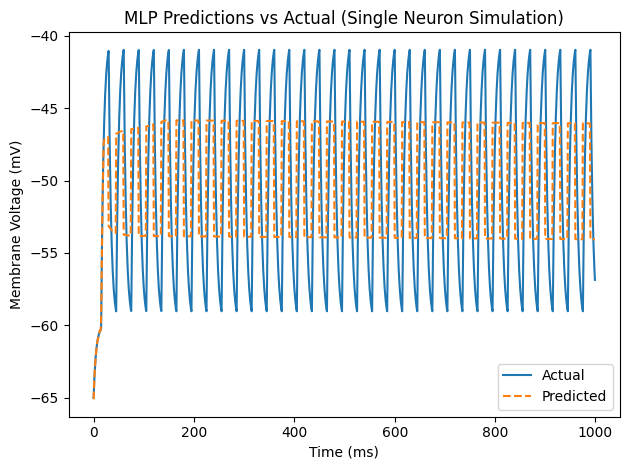

In [84]:
# Plot predictions vs actual
predicted_potentials = []
pred_times = []
n_samples = 1000
total = len(results["times"])
step_idx = max(1, total // n_samples)
model.eval()
with torch.no_grad():
    for idx in range(0, total, step_idx):
        t_val = results["times"][idx]
        ext = results["external_currents"][idx]
        input_tensor = torch.tensor(
            [[t_val, ext]], dtype=torch.float32).to(device)
        predicted_potential = model(input_tensor).item()
        predicted_potentials.append(predicted_potential)
        pred_times.append(t_val)

plt.plot(results["times"][::step_idx],
         results["potentials"][::step_idx], label="Actual")
plt.plot(pred_times, predicted_potentials,
         label="Predicted", linestyle="dashed")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Voltage (mV)")
plt.title("MLP Predictions vs Actual (Single Neuron Simulation)")
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion**: No, it can't be brute forced with a reasonably sized model